In [1]:
library("tidyverse")
library("infer") # for tests
library("lsr") # just for cohensD

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.6
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.1     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.2
✔ purrr     1.2.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [5]:
df <- ggplot2::diamonds
df |> head()

carat,cut,color,clarity,depth,table,price,x,y,z
<dbl>,<ord>,<ord>,<ord>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>
0.23,Ideal,E,SI2,61.5,55,326,3.95,3.98,2.43
0.21,Premium,E,SI1,59.8,61,326,3.89,3.84,2.31
0.23,Good,E,VS1,56.9,65,327,4.05,4.07,2.31
0.29,Premium,I,VS2,62.4,58,334,4.20,4.23,2.63
0.31,Good,J,SI2,63.3,58,335,4.34,4.35,2.75
0.24,Very Good,J,VVS2,62.8,57,336,3.94,3.96,2.48


# Inference
For inference the variable **depth** was chosen. It describes the height of a diamond from the **table** (flat top surface) to the **cutlet** (tip at the bottom) and can be measured in millimeters. In this Dataset it is relative to the width of the diamond, so it must be interpreted as a percentage. See [here](https://www.diamonds.pro/education/diamond-depth-and-table/) for further information.

In [6]:
confidence_level = 0.95
q_lower = (1 - confidence_level) / 2
q_upper = q_lower + confidence_level

df |> 
    pull(depth) |> 
    quantile(c(q_lower, q_upper)) |> 
    print() # For better formatting

 2.5% 97.5% 
 58.6  64.4 


## Test for Normal Distribution
The histogram and the qq-plot show pretty clearly that a normal distribution is very unlikely to be present. First we will create functions to plot our data against normal distribution.

In [17]:
options(repr.plot.width = 10, repr.plot.height = 4) # make plot wider

plot_depth_agains_norm <- function(df) {
    # scale standard-normal distribution with our data
    m <- mean(df$depth)
    s <- sd(df$depth)

    norm_density <- function(x) dnorm(x, 
        mean = m,
        sd = s
    )

    df |> 
    ggplot(aes(x = depth)) +
    geom_histogram(aes(y = after_stat(density)), bins = 70, 
                   fill = "#cccccc", color = "white", alpha = 0.85) + 
    geom_density(linewidth = 1.2, color = "#0073C2FF") +
    geom_function(fun = dnorm, args = list(mean = m, sd = s), 
                  linewidth = 1.2, color = "#006b3d", linetype = "dashed") +
    theme_minimal(base_size = 14) +
    labs(
        title = "Diamond Depth Distribution vs. Normal Curve",
        subtitle = paste0( # concats strings with no separator
            "Blue line = Sample Distribution\nDashed Green = Normal Distribution (µ=", round(m, 1), ", σ=", round(s, 1), ")"),
        x = "depth (%)",
        y = "density",
    ) +
    theme(
        panel.grid.minor = element_blank(),
        plot.title = element_text(face = "bold")
    )
}

qq_plot_depth <- function(df) {
    df |> 
    ggplot(aes(sample = depth)) + 
    stat_qq(color = "#0073C2FF") + 
    stat_qq_line(color="#006b3d", linewidth=1.5 , alpha=0.7) + 
    labs(title = "QQ-Plot depth", 
        x = "Quantiles Normaldistribution", 
        y = "Quantiles depth")
}

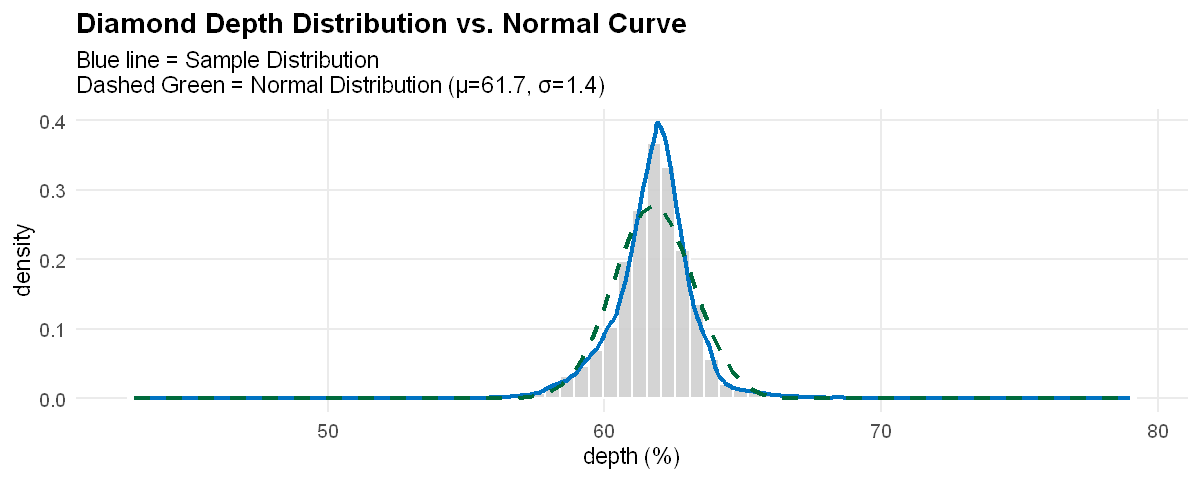

In [18]:
plot_depth_agains_norm(df)

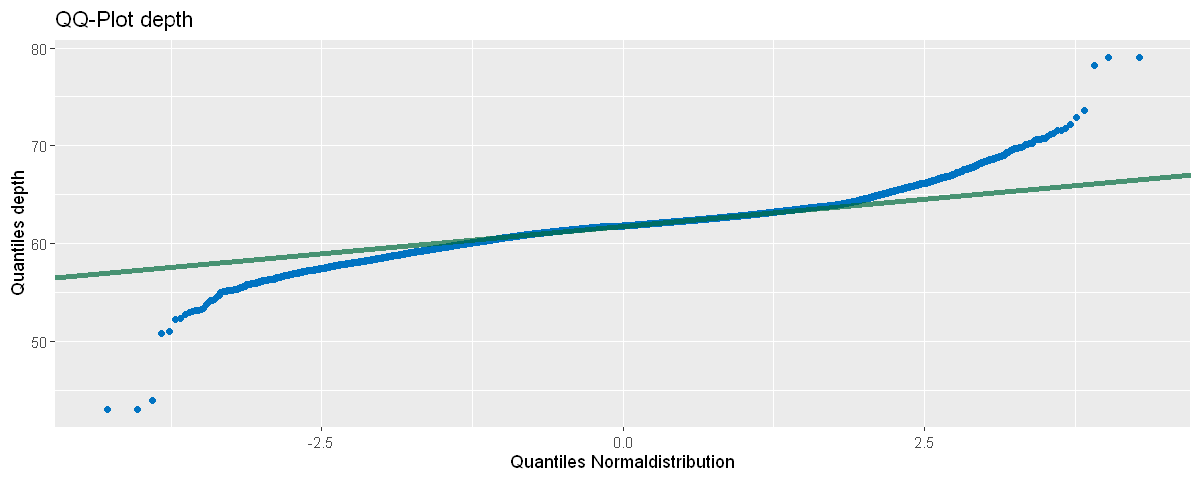

In [9]:
qq_plot_depth(df)

Now lets examine how removing the smallest and largest 1% of data changes the behavior.

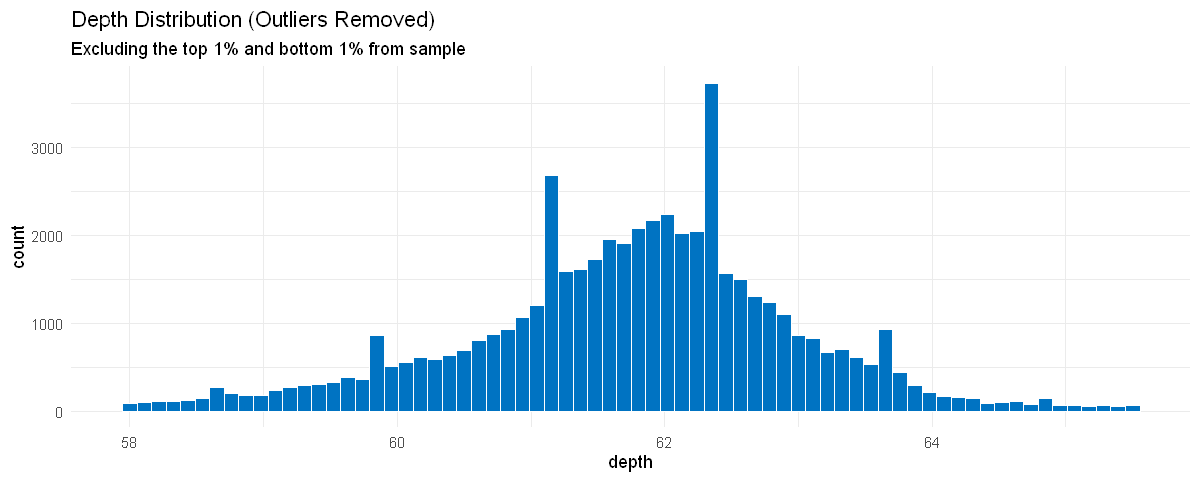

In [14]:
df_filtered <- df |> 
    filter(depth > quantile(depth, 0.01, na.rm = TRUE),
           depth < quantile(depth, 0.99, na.rm = TRUE))

df_filtered |> 
    ggplot(aes(x = depth)) +
    geom_histogram(bins = 70, fill = "#0073C2FF", color = "white") +
    theme_minimal() +
    labs(title = "Depth Distribution (Outliers Removed)",
         subtitle = "Excluding the top 1% and bottom 1% from sample")

We see in the histogram, that both functions came closer to each other but the qq-plot still shows some discrepancies. As expected mu has not changed but sigma did.

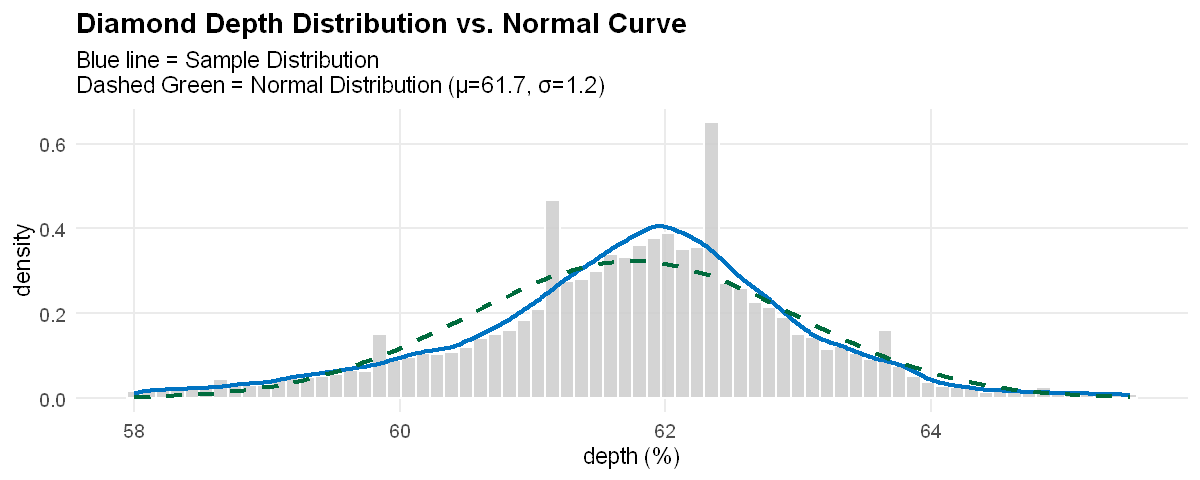

In [20]:
plot_depth_agains_norm(df_filtered)

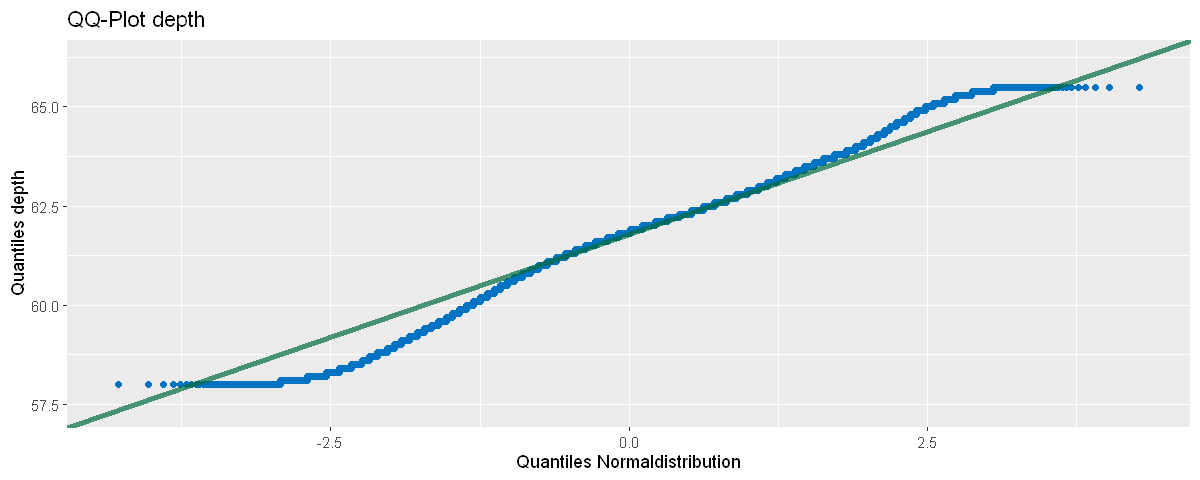

In [21]:
qq_plot_depth(df_filtered)

We can now test our **df** againts normal distribution to validate the assumptions from our plots.
Lets assume that: \
**H0:** "depth" follows normal distribution \
**H1:** "depth" does not follow normal distribution

In [24]:
ks.test(
    x=df$depth, 
    y="pnorm", # Test against normal distribution
    mean=mean(df$depth), 
    sd=sd(df$depth), 
    alternative = "two.sided" # Standard value
)

Warning message in ks.test.default(x = df$depth, y = "pnorm", mean = mean(df$depth), :
"ties should not be present for the one-sample Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  df$depth
D = 0.075871, p-value < 2.2e-16
alternative hypothesis: two-sided


We can see from the Kolmogorov-Smirnov test, that the p-value is very small so we need to **reject H0**. Now lets test **df_filtered** for normal distribution to see if sacrificing 2% of our data was worth it. Again we state that: \
**H0:** "depth" follows normal distribution \
**H1:** "depth" does not follow normal distribution


In [25]:
ks.test(
    x=df_filtered$depth, # now we use filtered data
    y="pnorm", # Test against normal distribution
    mean=mean(df$depth), 
    sd=sd(df$depth), 
    alternative = "two.sided" # Standard value
)

Warning message in ks.test.default(x = df_filtered$depth, y = "pnorm", mean = mean(df$depth), :
"ties should not be present for the one-sample Kolmogorov-Smirnov test"



	Asymptotic one-sample Kolmogorov-Smirnov test

data:  df_filtered$depth
D = 0.080987, p-value < 2.2e-16
alternative hypothesis: two-sided


Again p-value is really small so we have to **reject H0**. In conclusion it can be said, that there is very strong evidence, that our data (filtered and unfiltered) does not follow normal distribution.

## Directed T-Test
Based on our extensive knowledge about diamonds we came to the conclusion that the depth of a diamond has some kind of influence on its cut. This means that a diamond with a "Fair" cut should be more shallow than a diamond with an "Ideal" cut according to [this](https://www.diamondguidance.com/education/diamond-grading/4-cs/cut/fair/) article.

We state our Hypothesis like this: \
**H0**: Mean depth of "Fair" cut diamonds is less than (or equal) to the mean depth of "Ideal" cut diamonds \
**H1**: Mean depth of "Fair" cut diamonds is greater than the mean depth of "Ideal" cut diamonds

In [36]:
df_fair_ideal <- df |> filter(cut == "Fair" | cut == "Ideal")

df_fair_ideal |> t_test(
    formula = depth ~ cut, # compare depth, groups defined by cut
    alternative = "greater", # also see H1
    order = c("Fair", "Ideal"),
    conf_level=0.95, 
)

statistic,t_df,p_value,alternative,estimate,lower_ci,upper_ci
<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
25.64795,1618.363,2.514919e-122,greater,2.332276,2.182617,Inf


Since the p-value is very small (basically zero) we can **reject H0** and have strong evidence based on our data that the mean depth of "Fair" cut diamonds is grater than the mean depth of "Ideal" cut diamonds. Based on the conf_level of 95% and the lower_ci being at about 2.18% we can also state that we have 95% confidence that "Fair" cut diamonds are 2.18% deeper than "Ideal" cut diamonds.